# **Proyecto: Predicción del Precio de Diamantes**

**Base de datos:** `diamonds` — OpenML ID 42225
**Enlace:** https://www.openml.org/search?type=data&sort=runs&id=42225&status=active




## 1. Descripción de la base de datos

### Fuente y contexto general

El dataset **diamonds** (OpenML data ID 42225) es una base de datos ampliamente usada en la comunidad de ciencia de datos y machine learning. Fue publicada originalmente como conjunto de datos de ejemplo del paquete ggplot2 de R y luego incorporada a OpenML como benchmark estándar para problemas de regresión.

- **Número de instancias (filas):** 53.940 diamantes.
- **Número de variables:** 10 en total-
9 variables predictoras + 1 variable de salida (`price`).
- **Valores faltantes:** el dataset no reporta valores nulos

### Dominio del problema

El dominio corresponde al sector joyero / comercio de piedras preciosas. Cada fila representa un diamante individual, caracterizado por:

- Sus **4 C's** de calidad (estándar de la industria gemológica): *carat* (quilate/peso), *cut* (corte), *color* y *clarity* (claridad).
- Sus **dimensiones físicas**: largo (x), ancho (y) y profundidad (z) en milímetros, además de dos proporciones derivadas (depth y table).
- Su **precio de venta** en el mercado, en dólares estadounidenses (price).

### Utilidad / aplicación del problema

- **Motores de fijación de precios** para joyerías y plataformas de comercio electrónico de diamantes, que permiten sugerir un precio justo de venta a partir de las características físicas y de calidad de la piedra.
- **Tasación y avalúos automatizados** para aseguradoras y casas de empeño, que necesitan estimar el valor de un diamante sin depender exclusivamente del juicio de un experto.
- **Detección de anomalías de precio** diamantes sobrevalorados o subvalorados frente a piezas comparables, útil para auditoría y control de fraude.
- **caso de estudio**: al tener variables numéricas continuas y categóricas ordinales combinadas, es un excelente ejemplo para practicar preprocesamiento de datos, codificación de variables categóricas ordinales y modelos de regresión (lineal, árboles, ensambles, etc.).

### Descripción de las variables

| Variable  | Tipo de variable               | Descripción                                                                                    |
| --------- | ------------------------------ | ---------------------------------------------------------------------------------------------- |
| `carat`   | Numérica continua              | Peso del diamante, en quilates.                                                                |
| `cut`     | Categórica ordinal             | Calidad del corte: `Fair` < `Good` < `Very Good` < `Premium` < `Ideal`.                        |
| `color`   | Categórica ordinal             | Color del diamante, desde `D` (incoloro, mejor) hasta `J` (con tinte, peor).                   |
| `clarity` | Categórica ordinal             | Claridad/pureza: `I1` (peor) < `SI2` < `SI1` < `VS2` < `VS1` < `VVS2` < `VVS1` < `IF` (mejor). |
| `depth`   | Numérica continua              | Porcentaje de profundidad total = `2*z / (x+y)`.                                               |
| `table`   | Numérica continua              | Ancho de la cara superior del diamante respecto al punto más ancho de la piedra (%).           |
| `x`       | Numérica continua              | Longitud en milímetros.                                                                        |
| `y`       | Numérica continua              | Ancho en milímetros.                                                                           |
| `z`       | Numérica continua              | Profundidad en milímetros.                                                                     |
| `price`   | Numérica continua (salida)| Precio de venta del diamante, en dólares estadounidenses (USD).                                |


# 2. Descripción del problema

El mercado de diamantes es diferente a otro tipo de metales como lo es el oro y la plata. Los diamantes no tienen un precio cotizado en la bolsa de valores por lo que no tiene una referencia estándar de su precio en el mercado; sino que cada comerciante establece el valor final según unas características tanto cuantitativas (peso en quilates, dimensiones físicas) como cualitativas  (corte, color, claridad).

Desde la perspectiva de Machine Learning, nos enfrentamos a un problema de aprendizaje supervisado de regresión, dado que nuestra variable objetivo o de salida (**`price`**) es una variable numérica continua. Nuestro objetivo principal es construir un modelo predictivo capaz de aprender los patrones de las carcaterísticas de los diamantes para poder estimar o predecir su precio en el mercado (la variable está en dólares estadounidenses), obteniendo el modelo con el menor margen de error posible

##Carga de la base de datos

Se descarga la base de datos directamente desde OpenML usando la librería `openml`, indicando el ID del dataset (42225).

In [1]:
!pip install openml

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.8/93.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 27.4 MB/s eta 0:00:00
  Created wheel for liac-arff: filename=liac_arff-2.5.0-py3-none-any.whl size=11717 sha256=77d9f8abe7dd77d8e5a3ffea529edf12b06351fcff6035f15f2cbbffe5a32040
  Stored in directory: /root/.cache/pip/wheels/93/f3/5b/658a9bddee916a5f4b84bdc1a4e0fabd22fb17947c2c9542e6
Successfully built liac-arff


In [2]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
import openml
import numpy as np


In [3]:
# Cargar un dataset por su nombre
# as_frame=True devuelve un DataFrame de Pandas
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=True)

print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


In [4]:
# Descargar un dataset usando su ID o nombre
dataset = openml.datasets.get_dataset(42225)

# Obtener los datos como un DataFrame de Pandas
X, y, categorical_indicator, attribute_names = dataset.get_data(
    target=dataset.default_target_attribute
)

# Reconstruir un único DataFrame con todas las variables (predictoras + salida)
df = X.copy()
df[dataset.default_target_attribute] = y

print(f"Variable de salida detectada por OpenML: '{dataset.default_target_attribute}'")
print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

Variable de salida detectada por OpenML: 'price'
Dimensiones del dataset: 53940 filas x 10 columnas


,carat,cut,color,clarity,depth,table,x,y,z,price
0,0.23,Ideal,E,SI2,61.5,55.0,3.95,3.98,2.43,326
1,0.21,Premium,E,SI1,59.8,61.0,3.89,3.84,2.31,326
2,0.23,Good,E,VS1,56.9,65.0,4.05,4.07,2.31,327
3,0.29,Premium,I,VS2,62.4,58.0,4.20,4.23,2.63,334
4,0.31,Good,J,SI2,63.3,58.0,4.34,4.35,2.75,335


## 3. Análisis exploratorio de datos (EDA)

**Observación:** `carat`, `depth`, `table`, `x`, `y`, `z` y `price` como numéricas (float64/int64), y `cut`, `color`, `clarity` como categóricas (category / object)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   x        53940 non-null  float64 
 7   y        53940 non-null  float64 
 8   z        53940 non-null  float64 
 9   price    53940 non-null  int64   
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


### Valores faltantes

El dataset no presenta valores nulos declarados.

In [6]:
nulos = df.isnull().sum()
print("Valores nulos por variable:")
print(nulos)
print(f"\nTotal de valores nulos en el dataset: {nulos.sum()}")

Valores nulos por variable:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
x          0
y          0
z          0
price      0
dtype: int64

Total de valores nulos en el dataset: 0


### Valores duplicados

se identificaron 146 filas completamente duplicadas (idénticas en las 10 variables, incluyendo `price`). Como `carat`, `price` y las dimensiones físicas (`x`, `y`, `z`) son variables continuas con varios decimales, la probabilidad de que dos diamantes distintos coincidan exactamente en las diez columnas es prácticamente nula. Por lo tanto, estos registros corresponden a duplicación en la captura de los datos y no a diamantes diferentes con características casualmente iguales. Conservarlos no aporta información nueva y sobre-representaría esas observaciones en el entrenamiento del modelo.

In [7]:
duplicados = df.duplicated().sum()
print(f"Número de filas completamente duplicadas: {duplicados}")
print(f"Porcentaje del total: {duplicados / len(df) * 100:.3f}%")

df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(10)

Número de filas completamente duplicadas: 146
Porcentaje del total: 0.271%


,carat,cut,color,clarity,depth,table,x,y,z,price
43995,0.3,Good,J,VS1,63.4,57.0,4.23,4.26,2.69,394
47296,0.3,Good,J,VS1,63.4,57.0,4.23,4.26,2.69,394
34408,0.3,Ideal,G,IF,62.1,55.0,4.32,4.35,2.69,863
34422,0.3,Ideal,G,IF,62.1,55.0,4.32,4.35,2.69,863
28592,0.3,Ideal,G,VS2,63.0,55.0,4.31,4.29,2.71,675
28593,0.3,Ideal,G,VS2,63.0,55.0,4.31,4.29,2.71,675
31624,0.3,Ideal,H,SI1,62.2,57.0,4.26,4.29,2.66,450
31627,0.3,Ideal,H,SI1,62.2,57.0,4.26,4.29,2.66,450
31626,0.3,Ideal,H,SI1,62.2,57.0,4.27,4.28,2.66,450
31629,0.3,Ideal,H,SI1,62.2,57.0,4.27,4.28,2.66,450


Tras eliminar los duplicados, el dataset pasa de 53.940 a 53.794 registros únicos (se retiraron 146 filas), sin pérdida relevante de información para el análisis.

In [8]:
print(f"Filas antes de eliminar duplicados: {df.shape[0]}")
df = df.drop_duplicates().reset_index(drop=True)
print(f"Filas después de eliminar duplicados: {df.shape[0]}")

Filas antes de eliminar duplicados: 53940
Filas después de eliminar duplicados: 53794


### Estadística descriptiva de las variables numéricas

**Análisis de las variables numéricas:**

- **`carat`** (peso, quilates): variable de razón, rango teórico documentado 0.2–5.01. La media es cercana a 0.8 quilates y la distribución está sesgada a la derecha (la mayoría de los diamantes son pequeños; existen pocos ejemplares muy grandes que actúan como valores atípicos).
- **`depth`** y **`table`** (porcentajes de proporción): variables de razón con rango acotado 43–79% y 43–95% respectivamente.
- **`x`, `y`, `z`** (dimensiones físicas en mm): variables de razón. Se observa que el mínimo de estas tres variables es **0**, lo cual es físicamente imposible para un diamante real, un diamante no puede tener largo, ancho o profundidad nulos son valores erróneos/atípicos que deben limpiarse.
- **`price`** (variable de salida, USD) la mediana es bastante menor que la media, lo que indica que unos pocos diamantes muy costosos elevan el promedio. Rango documentado "$326 – $18.823".

In [9]:
num_cols = ["carat", "depth", "table", "x", "y", "z", "price"]
df[num_cols].describe()

,carat,depth,table,x,y,z,price
count,53794.00000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000
mean,0.79778,61.748080,57.458109,5.731214,5.734653,3.538714,3933.065082
std,0.47339,1.429909,2.233679,1.120695,1.141209,0.705037,3988.114460
min,0.20000,43.000000,43.000000,0.000000,0.000000,0.000000,326.000000
25%,0.40000,61.000000,56.000000,4.710000,4.720000,2.910000,951.000000
50%,0.70000,61.800000,57.000000,5.700000,5.710000,3.530000,2401.000000
75%,1.04000,62.500000,59.000000,6.540000,6.540000,4.030000,5326.750000
max,5.01000,79.000000,95.000000,10.740000,58.900000,31.800000,18823.000000


### Estadística descriptiva de las variables categóricas ordinales

**Análisis de las variables categóricas:**

- **`cut`**: variable categórica **ordinal** con 5 niveles (`Fair` < `Good` < `Very Good` < `Premium` < `Ideal`). La categoría `Ideal` es la más frecuente, seguida de `Premium`; `Fair` es la menos común.
- **`color`**: variable categórica **ordinal** con 7 niveles `D` a `J`, siendo `D` el mejor/más incoloro. Las categorías centrales (`G`, `E`, `F`) concentran la mayor cantidad de observaciones.
- **`clarity`**: variable categórica **ordinal** con 8 niveles `I1` a `IF`. Las categorías intermedias `SI1`, `VS2` son las más frecuentes; los extremos (`I1` muy incluido e `IF` internamente sin defectos) son minoritarios.


In [10]:
cat_cols = ["cut", "color", "clarity"]
for c in cat_cols:
    print(f"--- {c} ---")
    print(df[c].value_counts())
    print()

--- cut ---
cut
Ideal        21488
Premium      13748
Very Good    12069
Good          4891
Fair          1598
Name: count, dtype: int64

--- color ---
color
G    11262
E     9776
F     9520
H     8272
D     6755
I     5407
J     2802
Name: count, dtype: int64

--- clarity ---
clarity
SI1     13032
VS2     12229
SI2      9150
VS1      8156
VVS2     5056
VVS1     3647
IF       1784
I1        740
Name: count, dtype: int64



### Distribución de las variables numéricas (histogramas)

- `carat` y `price` muestran una clara cola larga hacia la derecha: la mayoría de los diamantes son pequeños y económicos, mientras que unos pocos son grandes y muy costosos.
- `depth` y `table` presentan distribuciones aproximadamente simétricas, concentradas alrededor de su valor estándar de tallado.
- `x`, `y` y `z` son también asimétricas y muestran una pequeña acumulación en 0, confirmando los valores atípicos detectados.

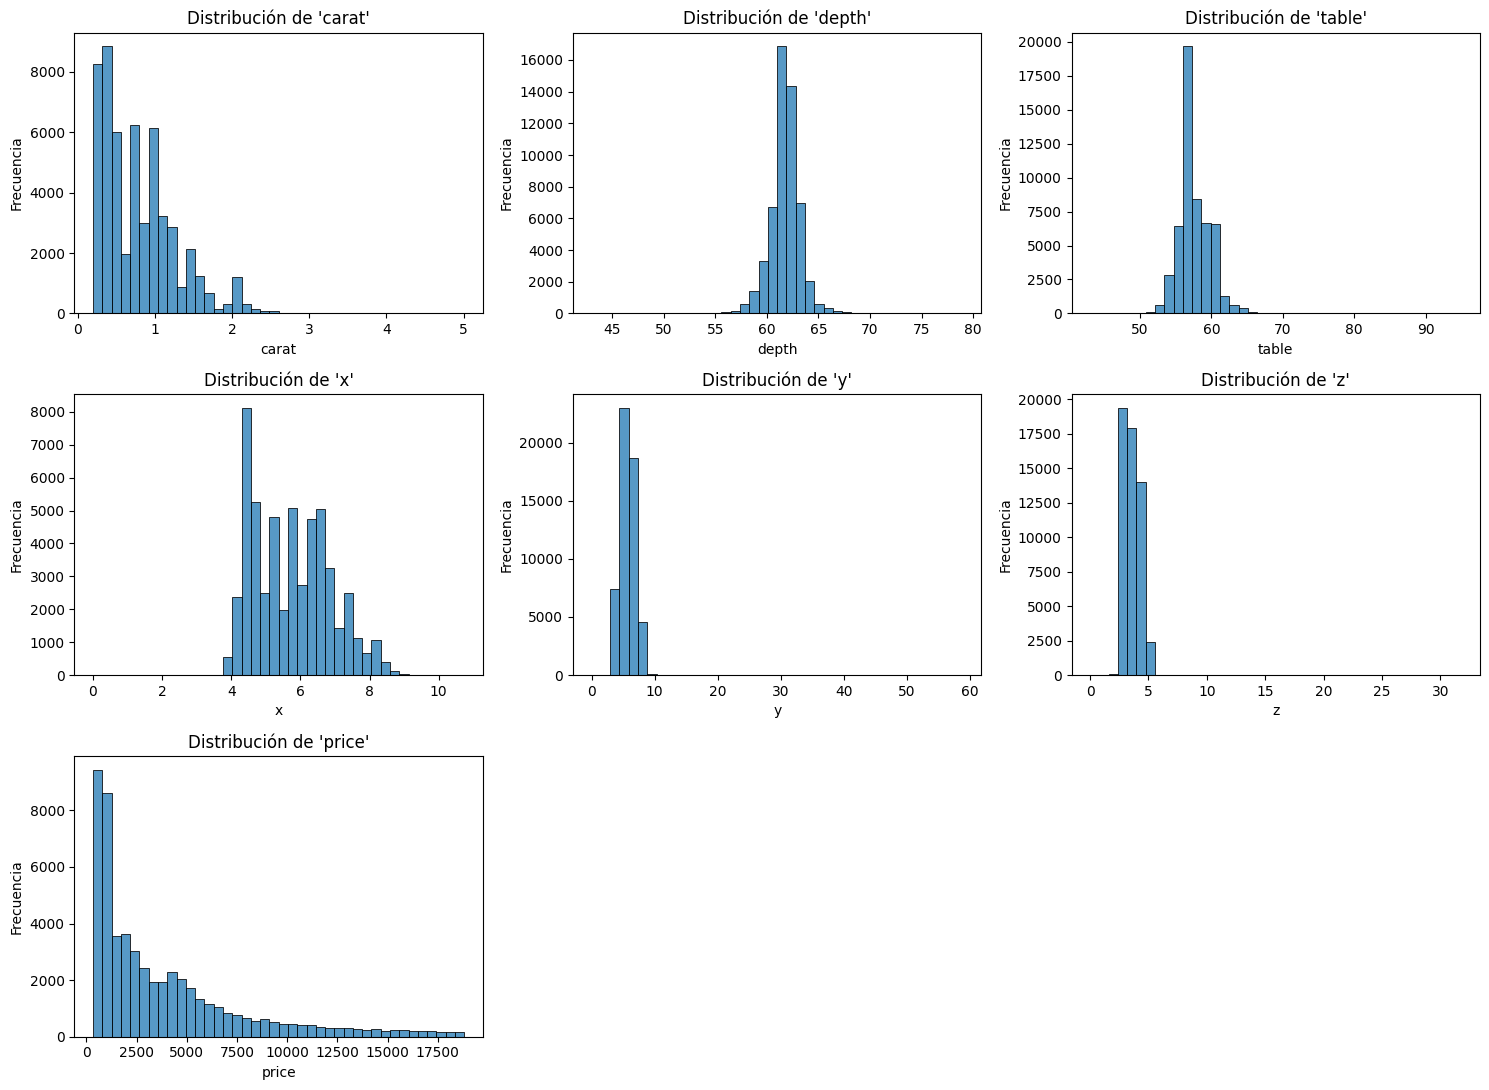

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))

axes = axes.flatten()

for i, col in enumerate(num_cols):

    sns.histplot(df[col], bins=40, ax=axes[i])

    axes[i].set_title(f"Distribución de '{col}'")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Distribución de las variables categóricas

Se confirma visualmente que `Ideal` domina en `cut`, que los colores centrales (`G`, `E`, `F`) son los más comunes, y que `SI1`/`VS2` concentran buena parte de las observaciones en `clarity`.

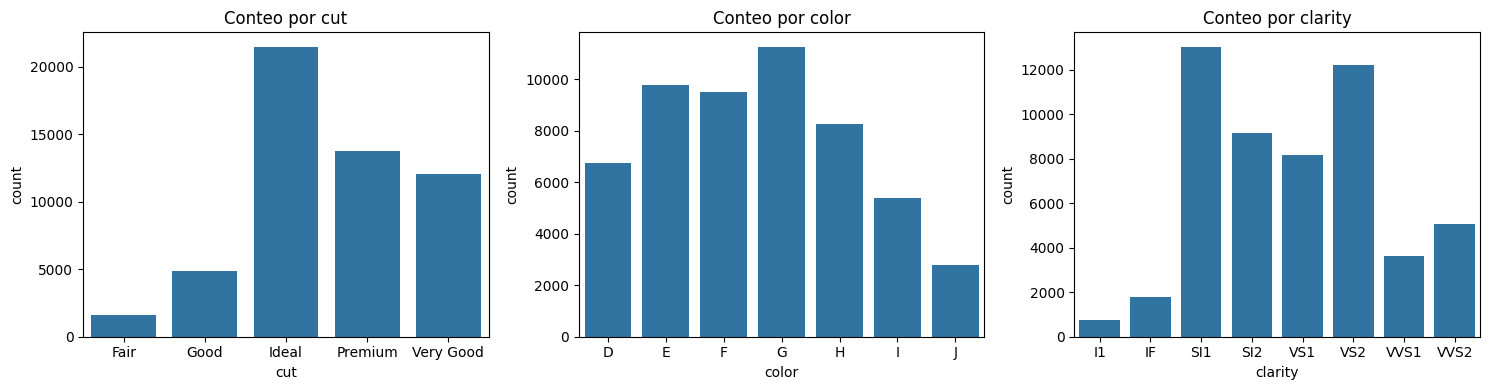

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(x="cut", data=df, ax=axes[0])
axes[0].set_title("Conteo por cut")

sns.countplot(x="color", data=df, ax=axes[1])
axes[1].set_title("Conteo por color")

sns.countplot(x="clarity", data=df, ax=axes[2])
axes[2].set_title("Conteo por clarity")

plt.tight_layout()
plt.show()

## Detección de valores atípicos (outliers)

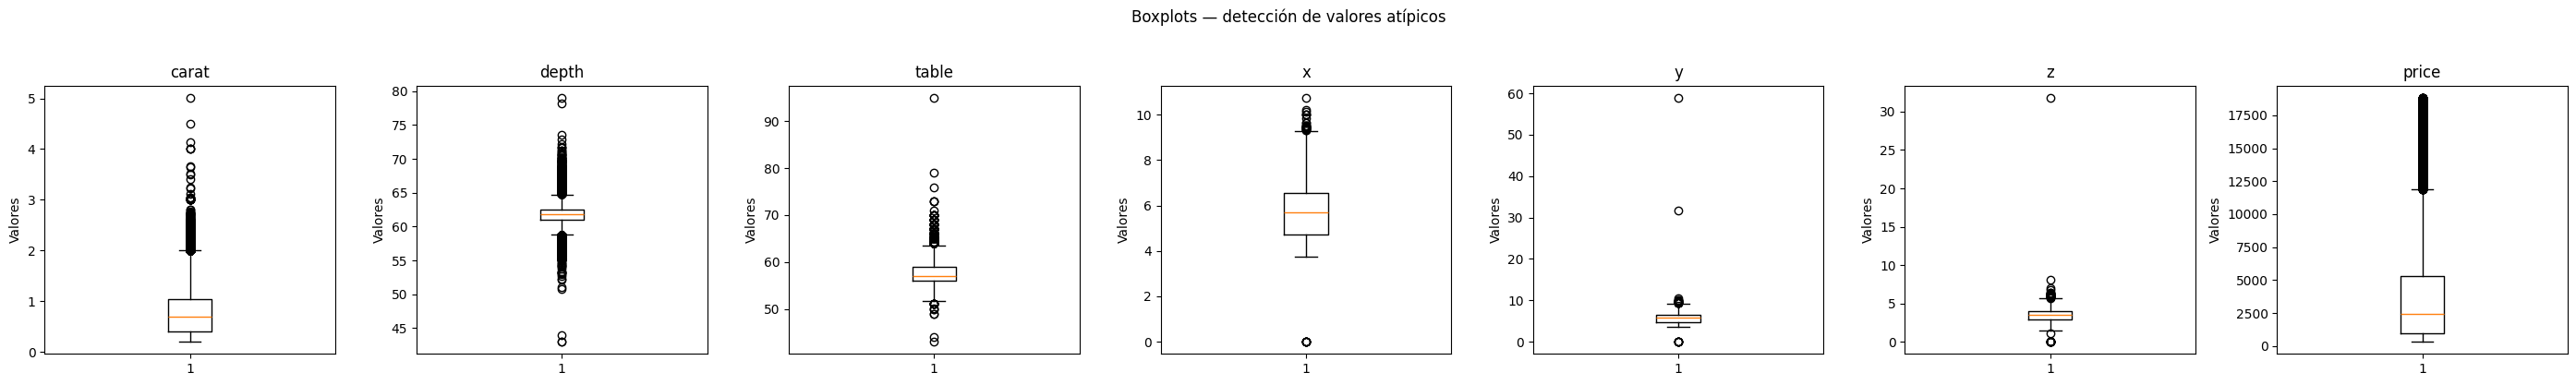

In [13]:
# Seleccionar todas las columnas numéricas
numericas = df.select_dtypes(include='number').columns

# Crear los gráficos
fig, axes = plt.subplots(
    1,
    len(numericas),
    figsize=(4 * len(numericas), 4)
)

# Si solo hay una variable numérica
if len(numericas) == 1:
    axes = [axes]

# Crear un boxplot para cada variable
for ax, col in zip(axes, numericas):
    ax.boxplot(df[col].dropna(), vert=True)
    ax.set_title(col)
    ax.set_ylabel('Valores')

plt.suptitle(
    'Boxplots — detección de valores atípicos',
    y=1.03
)

plt.tight_layout()
plt.show()

### Análisis y tratamiento de valores en 0 para x, y, z

se detectaron 19 diamantes con al menos una de sus dimensiones físicas (`x`, `y` o `z`) registrada en 0. Un diamante con largo, ancho o profundidad de 0 mm no puede existir: se trata de errores de captura/medición y no de observaciones válidas, tal como ya se había advertido en la estadística descriptiva y en los histogramas y boxplots anteriores. En varios casos las tres dimensiones son 0 simultáneamente, y en el resto solo `z` (la profundidad) aparece en 0 mientras `x` e `y` sí son coherentes con el `carat` del diamante. Dado que representan una fracción mínima del dataset y que en varios registros no es posible reconstruir con certeza las tres dimensiones originales, se opta por tratarlos como valores faltantes y eliminarlos

In [14]:
cond_cero = (df["x"] == 0) | (df["y"] == 0) | (df["z"] == 0)
print(f"Filas con x, y o z igual a 0: {cond_cero.sum()}")
print(f"Porcentaje del total: {cond_cero.sum() / len(df) * 100:.3f}%\n")

df.loc[cond_cero, ["carat", "x", "y", "z", "price"]]

Filas con x, y o z igual a 0: 19
Porcentaje del total: 0.035%



,carat,x,y,z,price
2201,1.00,6.55,6.48,0.0,3142
2308,1.01,6.66,6.60,0.0,3167
4778,1.10,6.50,6.47,0.0,3696
5457,1.01,6.50,6.47,0.0,3837
10145,1.50,7.15,7.04,0.0,4731
11156,1.07,0.00,6.62,0.0,4954
11935,1.00,0.00,0.00,0.0,5139
13570,1.15,6.88,6.83,0.0,5564
15914,1.14,0.00,0.00,0.0,6381
24338,2.18,8.49,8.45,0.0,12631


In [15]:
# Los ceros no tienen sentido físico: se tratan como valores faltantes y se eliminan las filas afectadas
df[["x", "y", "z"]] = df[["x", "y", "z"]].replace(0, np.nan)

filas_antes = df.shape[0]
df = df.dropna(subset=["x", "y", "z"]).reset_index(drop=True)
filas_despues = df.shape[0]

print(f"Filas antes de tratar los ceros en x, y, z: {filas_antes}")
print(f"Filas después de eliminar los registros con dimensiones en 0: {filas_despues}")
print(f"Filas eliminadas: {filas_antes - filas_despues}")

Filas antes de tratar los ceros en x, y, z: 53794
Filas después de eliminar los registros con dimensiones en 0: 53775
Filas eliminadas: 19


## Correlación entre variables numéricas

Como se observa en la matriz, esta confirma que el peso (`carat`)  y las dimensiones (`x, y, z`) son los predictores más importantes del precio del diamante, con una relación casi lineal. (`depth`) y (`table`) tienen una influencia mucho menor en el precio y estas pueden ser más relevantes para la calidad del corte que para el tamaño o el precio directamente.

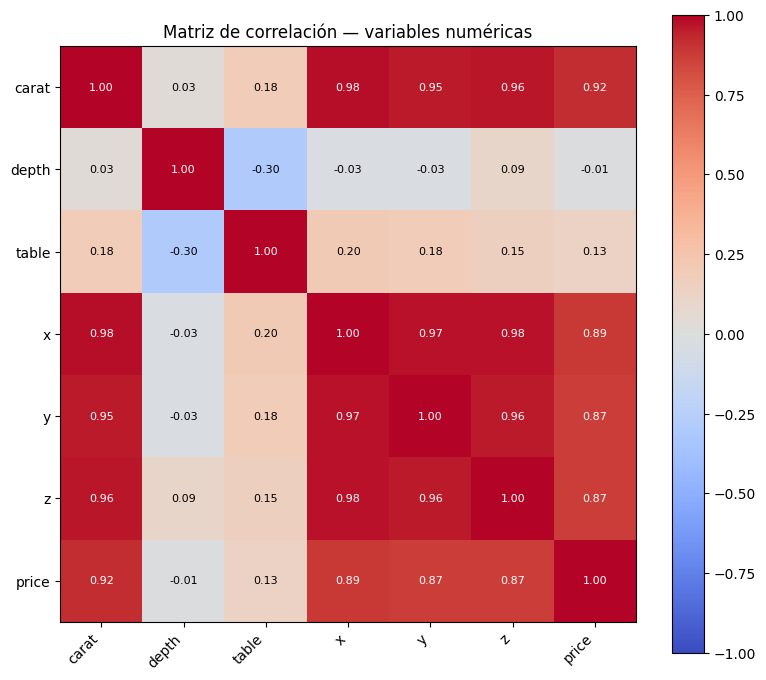

In [16]:
num_cols = df.select_dtypes(include='number').columns.tolist()
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols))); ax.set_xticklabels(num_cols, rotation=45, ha='right')
ax.set_yticks(range(len(num_cols))); ax.set_yticklabels(num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=8,
                color='white' if abs(corr.iloc[i,j]) > 0.5 else 'black')
fig.colorbar(im)
ax.set_title('Matriz de correlación — variables numéricas')
plt.tight_layout()
plt.show()

#Carga de Datos

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import GridSearchCV

In [18]:
# Variables predictoras numéricas y categóricas ordinales
num_features = ["carat", "depth", "table", "x", "y", "z"]
ord_features = ["cut", "color", "clarity"]

# Orden de calidad de cada variable ordinal, de peor a mejor
cut_order = ["Fair", "Good", "Very Good", "Premium", "Ideal"]
color_order = ["J", "I", "H", "G", "F", "E", "D"]
clarity_order = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]

# Matriz de predictoras y variable de salida

X_model = df[num_features + ord_features].copy()
y_model = df["price"].copy()

# División en entrenamiento 80% y prueba 20%

X_train, X_test,y_train, y_test = train_test_split(
    X_model, y_model, test_size=0.2, random_state=42
)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")

# Reprocesador : escalado para numérricas y codificación ordinal para categórias

preprocesador = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("ord", OrdinalEncoder(categories=[cut_order, color_order, clarity_order]), ord_features)
    ])

Dimensiones de X_train: (43020, 9)
Dimensiones de X_test: (10755, 9)


# 4. Entrenamiento del modelo y Metodología de validación  


En esta fase procedemos a configurar y entrenar el modelo de regresión utilizando el algoritmo de Gradiente Descendente Estocástico (`SGDRegressor`).

**Metodología de Validación:**

Para garantizar la capacidad de generalización del modelo y evitar el sobreajuste (*overfitting*), se implementa una metodología de **Validación Cruzada con 10 particiones (*10-Fold Cross-Validation*)**. El conjunto de datos de entrenamiento se divide aleatoriamente en 10 subconjuntos; el modelo se entrena iterativamente en 9 de ellos y se evalúa en el restante. El desempeño final se reporta como el promedio del Error Cuadrático Medio (ECM) obtenido.



In [22]:
# pipeline

pipeline_gd = Pipeline([
    ("preprocesador", preprocesador),
    ("modelo", SGDRegressor(random_state=42))
])

# validación cruzada de 10 folds

cv_10 = KFold (n_splits=10, shuffle=True, random_state=42)
scores_neg_ecm = cross_val_score(pipeline_gd, X_train, y_train, cv=cv_10, scoring="neg_mean_squared_error")

ecm_baseline = -scores_neg_ecm


Tras entrenar el modelo de regresión mediante el algoritmo de Gradiente Descendiente e implementar una validación cruzada de 10 folds, obtuvimos las siguientes métricas de desempeño sobre la variable objetivo


*   ECM promedio: $1,500,746.59
*   Desviación ECM: 138,606.74
*   RMSE promedio: 1,225.05


El RMSE que presenta este modelo significa que el modelo se está desviando, en promedio, $1,225 dólares al estimar el precio del diamante.

Por otro lado, tenemos una desviación estándar del ECM de 138,606 lo cual es relativamente bajo en comparación de la magnitud del ECM (representando aproximadamente un 9% del error promedio). Esto es un buen indicador que muestra la robustez del modelo.

In [23]:
print(f"ECM promedio: {ecm_baseline.mean():.2f}")
print(f"Desviación estandar del ECM: {ecm_baseline.std():.2f}")
print(f"RMSE promedio: {np.sqrt(ecm_baseline.mean()):.2f}")


ECM promedio: 1500673.11
Desviación estandar del ECM: 116086.82
RMSE promedio: 1225.02


# 5. Optimización de Hiperparámetros
Para refinar la capacidad predictiva del algoritmo y cumplir con el objetivo de optimización, implementamos una búsqueda exhaustiva (`GridSearchCV`) sobre el modelo `SGDRegressor`. Se iteró sobre diferentes combinaciones de regularización (L1, L2 y ElasticNet), constantes de penalización (`alpha`) y tasas de aprendizaje iniciales (`eta0`), conservando la validación cruzada de 10 *folds* para garantizar la robustez estadística de los resultados.






In [24]:
param_grid = {
    "modelo__penalty": ["l1", "l2", "elasticnet" ],
    "modelo__alpha"  : [0.0001, 0.001, 0.01],
    "modelo__eta0": [0.001, 0.01],
    "modelo__max_iter":  [1000]
    }

grid_search = GridSearchCV(estimator=pipeline_gd,
                           param_grid= param_grid,
                           cv=cv_10,
                           scoring="neg_mean_squared_error")
grid_search.fit(X_train, y_train)



GridSearchCV(cv=KFold(n_splits=10, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocesador',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['carat',
                                                                          'depth',
                                                                          'table',
                                                                          'x',
                                                                          'y',
                                                                          'z']),
                                                                        ('ord',
                                                                         OrdinalEncoder(categories=[['Fair',
                                                                                                     'Good',
                                                                                                     'Very '
                                                                                                     'Good',
                                                                                                     'Premium',
                                                                                                     'Ideal'],
                                                                                                    ['J',
                                                                                                     'I',
                                                                                                     'H',
                                                                                                     'G',
                                                                                                     'F',
                                                                                                     'E',
                                                                                                     'D'],
                                                                                                    ['I1',
                                                                                                     'SI2',
                                                                                                     'SI1',
                                                                                                     'VS2',
                                                                                                     'VS1',
                                                                                                     'VVS2',
                                                                                                     'VVS1',
                                                                                                     'IF']]),
                                                                         ['cut',
                                                                          'color',
                                                                          'clarity'])])),
                                       ('modelo',
                                        SGDRegressor(random_state=42))]),
             param_grid={'modelo__alpha': [0.0001, 0.001, 0.01],
                         'modelo__eta0': [0.001, 0.01],
                         'modelo__max_iter': [1000],
                         'modelo__penalty': ['l1', 'l2', 'elasticnet']},
             scoring='neg_mean_squared_error')

**Análisis Comparativo y Resultados:**

El algoritmo encontró su mejor desempeño utilizando una penalización **L2**, con un `alpha` de 0.0001 y una tasa de aprendizaje inicial (`eta0`) de 0.001.

El ECM se redujo de **1,500,746.59** (modelo base) a **1,490,294.09**. Y a su vez el RMSE pasó de 1,225 a 1,220.

In [26]:
print("Mejores hiperparámetros encontrados:")
print(grid_search.best_params_)
print(f"Mejor ECM: {-grid_search.best_score_:.2f}")
print(f"Mejor RMSE: {np.sqrt(-grid_search.best_score_):.2f}")

Mejores hiperparámetros encontrados:
{'modelo__alpha': 0.0001, 'modelo__eta0': 0.001, 'modelo__max_iter': 1000, 'modelo__penalty': 'l2'}
Mejor ECM: 1490294.09
Mejor RMSE: 1220.78



Por último, se extraen y tabulan los resultados de todas las iteraciones evaluadas durante la búsqueda de la malla. Esta vista consolidada permite analizar el impacto específico que tienen los distintos niveles de regularización (`penalty` y `alpha`) y la tasa de aprendizaje inicial (`eta0`) sobre la métrica de evaluación principal (`mean_test_score`, representada como el ECM negativo) y sobre la volatilidad predictiva del algoritmo en los 10 *folds* (`std_test_score`). La tabla se ordena descendente por puntaje, ubicando las configuraciones más eficientes en la parte superior.


Más allá de la mejora en la métrica principal de error (ECM), el hallazgo más significativo de la búsqueda en malla radica en la reducción de la varianza del algoritmo. El modelo base presentaba una desviación estándar de 138,606 a lo largo de las 10 particiones de validación. Sin embargo, la configuración óptima logró disminuir esta dispersión a 99,844. Esto representa una reducción de la volatilidad del 28%, lo que estadísticamente se traduce en un modelo sustancialmente más estable, robusto y con un riesgo mucho menor de sobreajuste (overfitting) al momento de enfrentarse a datos nuevos.

In [27]:
resultados = pd.DataFrame(grid_search.cv_results_)
resultados = resultados.sort_values(by="mean_test_score", ascending=False)

columnas_interes=["param_modelo__penalty", "param_modelo__alpha", "param_modelo__eta0", "mean_test_score", "std_test_score"]
resultados[columnas_interes]

,param_modelo__penalty,param_modelo__alpha,param_modelo__eta0,mean_test_score,std_test_score
1,l2,0.0001,0.001,-1.490294e+06,99844.073110
2,elasticnet,0.0001,0.001,-1.490613e+06,100245.014072
12,l1,0.0100,0.001,-1.490665e+06,100780.082025
6,l1,0.0010,0.001,-1.490681e+06,100829.549150
0,l1,0.0001,0.001,-1.490683e+06,100834.474636
8,elasticnet,0.0010,0.001,-1.491976e+06,98349.023898
7,l2,0.0010,0.001,-1.492326e+06,97974.274404
10,l2,0.0010,0.010,-1.498581e+06,106016.025900
11,elasticnet,0.0010,0.010,-1.499032e+06,107580.347879
4,l2,0.0001,0.010,-1.500673e+06,116086.824134


#Conclusiones

* El modelo de regresión lineal optimizado (mediante SGD) alcanzó un Error Cuadrático Medio (ECM) de aproximadamente 1,490,294, lo que se traduce en una desviación promedio (RMSE) de 1,220 dólares por diamante. Si bien establece una línea base sólida para la tasación automatizada, este margen de error sugiere que el modelo podría ser altamente preciso para diamantes de gama alta (donde $1,220 representa un porcentaje bajo del precio total), pero tendría limitaciones para la valoración precisa de diamantes de menor denominación comercial.

* La búsqueda de hiperparámetros mediante GridSearchCV demostró ser muy importante, no tanto por la reducción drástica del margen de error, sino por el aumento en la estabilidad del modelo. Al converger hacia una regularización L2 con un parámetro de penalización de 0.0001, la volatilidad de los errores entre los folds (desviación estándar) se redujo en más de un 28% (pasando de 138,000 a 99,800). Esto garantiza un algoritmo predictivo mucho más robusto frente a fluctuaciones en los datos de entrada.





